# <font color=' palegreen'>Data Science CA</font>

<font color='palegreen'>Aidin Kazemi: 810101561</font>

<font color='palegreen'>Ali Zilouchi: 810101560</font>

<font color='palegreen'>Paria Pasehvarz: 810101393</font>

## <font color='orange'>**Task 3 - LLM for MCQs**</font>

### <font color='skyblue'>1. Hugging face access token</font>

In [1]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Initialize the UserSecretsClient
user_secrets = UserSecretsClient()

# Get the stored secret
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login to Hugging Face using the secret
login(token=hf_token)

### <font color='skyblue'>2. Loading the dataset</font>

In [2]:
from datasets import load_dataset

# Load the "regular" configuration of the SWAG dataset
swag_dataset = load_dataset("swag", "regular")

# Print the dataset object to see its structure
print(swag_dataset)

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20005
    })
})


In [3]:
# Access the training split and view the first example
example = swag_dataset["train"][0]

# Print the example to see its fields
for key, value in example.items():
    print(f"{key}: {value}")

video-id: anetv_jkn6uvmqwh4
fold-ind: 3416
startphrase: Members of the procession walk down the street holding small horn brass instruments. A drum line
sent1: Members of the procession walk down the street holding small horn brass instruments.
sent2: A drum line
gold-source: gold
ending0: passes by walking down the street playing their instruments.
ending1: has heard approaching them.
ending2: arrives and they're outside dancing and asleep.
ending3: turns the lead singer watches the performance.
label: 0


### <font color='skyblue'>3. Analyse the dataset </font>

Each row represents a distinct commonsense reasoning problem. The goal is to choose the most logical continuation of a sentence describing a video clip.

* startphrase / sent1: This is the first part of the context, setting the scene. It's often a complete sentence.

* sent2: This is the second sentence of the context, describing an action that follows the first sentence. The model's task is to predict what logically happens next.

* ending0, ending1, ending2, ending3: These are the four possible multiple-choice options that could follow sent2.

label: This is the ground truth. It's an integer (0, 1, 2, or 3) indicating which of the endings is the correct, most logical continuation.

* gold-source: This indicates the origin of the correct answer (the "gold" standard). For this dataset, the correct endings come from the video captions themselves, while the incorrect ones (distractors) are machine-generated.

So, for each example, a model must understand the context provided by sent1 + sent2 and determine which of the four endings is the most plausible, as indicated by the label.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the training split to a Pandas DataFrame for easier analysis
df = swag_dataset["train"].to_pandas()

#### 1. Label Distribution

Let's see if the correct answers are evenly distributed among the four choices. An imbalanced distribution could potentially bias a model.

label
0    18414
1    18334
2    18340
3    18458
Name: count, dtype: int64


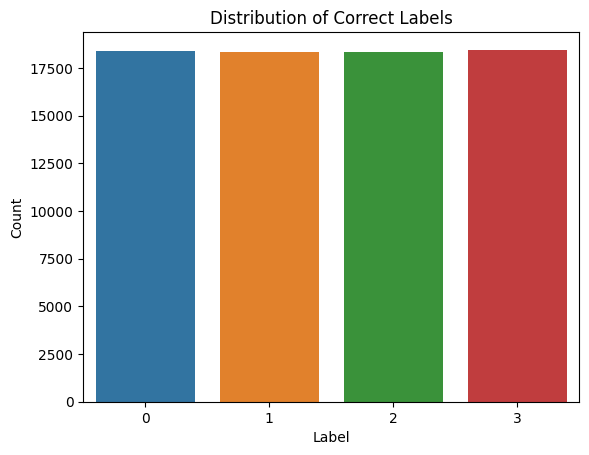

In [5]:
# Check the distribution of the labels
label_counts = df['label'].value_counts().sort_index()
print(label_counts)

# Plot the distribution
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribution of Correct Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

The dataset is perfectly balanced. Each of the four choices (0, 1, 2, 3) appears as the correct answer an almost equal number of times. This is ideal, as it prevents the model from simply learning to favor one position over the others.

#### 2. Text Length Analysis

Let's analyze the length of the sentences. This helps us understand the complexity and the amount of text a model needs to process for each example.

In [6]:
# Calculate the number of words in the context and endings
df['context_length'] = df['sent1'].str.split().str.len() + df['sent2'].str.split().str.len()
df['ending0_length'] = df['ending0'].str.split().str.len()
df['ending1_length'] = df['ending1'].str.split().str.len()
df['ending2_length'] = df['ending2'].str.split().str.len()
df['ending3_length'] = df['ending3'].str.split().str.len()

# Display summary statistics for the lengths
print(df[['context_length', 'ending0_length', 'ending1_length', 'ending2_length', 'ending3_length']].describe())

       context_length  ending0_length  ending1_length  ending2_length  \
count    73546.000000    73546.000000    73546.000000    73546.000000   
mean        14.057991        8.572852        8.606763        8.579828   
std          6.744379        3.975163        3.989374        3.996487   
min          4.000000        1.000000        1.000000        1.000000   
25%          9.000000        5.000000        6.000000        5.000000   
50%         13.000000        8.000000        8.000000        8.000000   
75%         17.000000       11.000000       11.000000       11.000000   
max        101.000000       25.000000       25.000000       25.000000   

       ending3_length  
count    73546.000000  
mean         8.557787  
std          3.987558  
min          1.000000  
25%          5.000000  
50%          8.000000  
75%         11.000000  
max         25.000000  


The text segments are relatively short. On average, the context is about 14 words long, and each ending is around 7-9 words long. The maximum lengths are also manageable, so we likely won't need to worry about complex text truncation strategies for most models.

#### 3. Source of Correct Endings

Let's check the gold-source column to see where the correct answers came from.

In [7]:
# Check the unique values and their counts in the 'gold-source' column
print(df['gold-source'].value_counts())

gold-source
gold    47928
gen     25618
Name: count, dtype: int64


This means the correct endings in your training set come from two different origins:

* gold (47,928 examples): This represents the "gold standard" answers. These are the endings taken directly from the original source, which are the human-written video captions. They represent natural, real-world continuations.

* gen (25,618 examples): This likely stands for "generated." It indicates that for a significant portion of the dataset, the correct answer was also generated, though likely by a different, more reliable process than the one used to create the incorrect distractors.

### <font color='skyblue'>4. Preprocess the dataset </font>

#### 1. Setup the Tokenizer

This step initializes the tokenizer that will convert our text into numerical IDs the model can understand.

In [8]:
from transformers import AutoTokenizer

# Load a tokenizer. DistilBERT is a good, fast choice.
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

#### 2. Create the Preprocessing Function

This function will take a batch of examples from the dataset and restructure them into the required format.

In [9]:
def preprocess_function(examples):
    contexts = [f"{s1} {s2}" for s1, s2 in zip(examples['sent1'], examples['sent2'])]
    first_sentences = [context for context in contexts for _ in range(4)]
    
    second_sentences = []
    for i in range(len(examples['sent1'])):
        second_sentences.append(examples['ending0'][i])
        second_sentences.append(examples['ending1'][i])
        second_sentences.append(examples['ending2'][i])
        second_sentences.append(examples['ending3'][i])
        
    tokenized_examples = tokenizer(first_sentences, second_sentences, truncation=True)
    
    result = {k: [v[i:i+4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = examples["label"]
    return result

# Re-run the map function
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

#### 3. Apply the Function to the Dataset

Now, we use the .map() method to apply this function across the entire SWAG dataset. Using batched=True is essential for efficiency and allows our function to process multiple examples at once.

In [10]:
# Apply the preprocessing function to the entire dataset
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

#### 4. Verify the Output

In [11]:
# Inspect the first example
example = tokenized_swag["train"][0]

# Print the keys to see the new structure
print(example.keys())

# Check the shape of the input_ids. It should be 4 lists of token IDs.
print(f"\nNumber of choices: {len(example['input_ids'])}")
print(f"Length of first choice's tokens: {len(example['input_ids'][0])}")

# Decode the first tokenized choice to see the final formatted input
print("\nDecoded first full input:")
print(tokenizer.decode(example['input_ids'][0]))

dict_keys(['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'attention_mask'])

Number of choices: 4
Length of first choice's tokens: 30

Decoded first full input:
[CLS] members of the procession walk down the street holding small horn brass instruments. a drum line [SEP] passes by walking down the street playing their instruments. [SEP]


### <font color='skyblue'>5. Load a tokenizer </font>

In [12]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

### <font color='skyblue'>6. Apply the preprocessing function  </font>

In [13]:
# Apply the preprocessing function to the entire dataset
tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

# You can then print the result to see the updated dataset structure
print(tokenized_swag)

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20005
    })
})


### <font color='skyblue'>7. Padding </font>

In [14]:
from transformers import DataCollatorForMultipleChoice

# Initialize the data collator
# It needs the tokenizer to know which token to use for padding
data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

2025-09-17 09:24:40.576389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758101080.596311   24562 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758101080.603562   24562 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### <font color='skyblue'>8. Load the model </font>

In [15]:
from transformers import AutoModelForMultipleChoice, TrainingArguments, Trainer
model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### <font color='skyblue'>9. Test the model on the dataset </font>

#### 1. Test Case Analysis

In [16]:
# Tell the dataset to only return these columns as PyTorch tensors
columns_to_keep = ['input_ids', 'token_type_ids', 'attention_mask', 'label']
tokenized_swag.set_format(type='torch', columns=columns_to_keep)

In [17]:
import torch

# --- Final Corrected Analysis Block ---

# 1. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Select the example
example_index = 42
# Get the full example from the correctly preprocessed dataset
single_example = tokenized_swag["validation"][example_index]
# Get the original text for printing the final analysis
original_example = swag_dataset["validation"][example_index]

# 3. Manually create a clean dictionary for the collator
# This ensures the collator only sees the data it can handle.
features_for_collator = {
    "input_ids": single_example["input_ids"],
    "attention_mask": single_example["attention_mask"],
    "token_type_ids": single_example["token_type_ids"],
    "label": single_example["label"]
}

# 4. Pass the clean dictionary to the collator
# Note: it must be wrapped in a list.
collated_batch = data_collator([features_for_collator])

# 5. Move the collated batch to the correct device
collated_batch = {k: v.to(device) for k, v in collated_batch.items()}

# 6. Perform inference
model.eval()
with torch.no_grad():
    outputs = model(**collated_batch)

logits = outputs.logits
predicted_label = logits.argmax().item()
# Get the ground truth from the original, complete example
ground_truth_label = single_example['label'] 

# --- Analysis ---
print(f"Context: {original_example['startphrase']}")
print("-" * 30)
for i in range(4):
    prefix = "[PREDICTED]" if i == predicted_label else "           "
    prefix += " [CORRECT]" if i == ground_truth_label else ""
    print(f"{prefix} Choice {i}: {original_example[f'ending{i}']}\n")

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Context: He takes out some clippers and clips some of the roots. Last, the video
------------------------------
[PREDICTED] Choice 0: cuts to a sharpener and how much he was trying.

            [CORRECT] Choice 1: ends with the closing captions.

            Choice 2: shows him grabbing a bow, hanging fish and trimming the hedge.

            Choice 3: ends with the color of scissors and cuts.



#### 2. Comprehensive Validation Set Evaluation

In [18]:
!pip install evaluate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [19]:
import evaluate
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Load the accuracy metric
accuracy_metric = evaluate.load("accuracy")

# 2. Create a DataLoader to handle batching
validation_dataloader = DataLoader(
    tokenized_swag["validation"],
    batch_size=8, 
    collate_fn=data_collator,
)

# 3. Evaluation loop
model.eval()
for batch in tqdm(validation_dataloader, desc="Evaluating"):
    # Move batch to the correct device
    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)
    
    # Add the predictions and ground truth labels for this batch to the metric
    accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])

# 4. Compute and print the final accuracy
final_accuracy = accuracy_metric.compute()
print(f"\nOverall Validation Accuracy: {final_accuracy['accuracy']:.4f}")

Evaluating: 100%|██████████| 2501/2501 [03:52<00:00, 10.77it/s]


Overall Validation Accuracy: 0.2251


### <font color='skyblue'>10. Use in-context learning (ICL) </font>

#### Technique 1: Few-Shot ICL

In [20]:
import torch
import evaluate
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Step 1: Define and apply the ICL preprocessing to the ORIGINAL dataset ---
# We start with `swag_dataset` because the function needs the original text columns.
shot_context = "A man is in a kitchen making a sandwich. He places a slice of bread on a plate and"
shot_correct_ending = "reaches for a jar of peanut butter."
shot_example_string = f"Example: {shot_context} {shot_correct_ending}\n\n"

def preprocess_function_few_shot(examples):
    contexts = [f"{shot_example_string}{s1} {s2}" for s1, s2 in zip(examples['sent1'], examples['sent2'])]
    first_sentences = [context for context in contexts for _ in range(4)]
    second_sentences = []
    for i in range(len(examples['sent1'])):
        second_sentences.append(examples['ending0'][i])
        second_sentences.append(examples['ending1'][i])
        second_sentences.append(examples['ending2'][i])
        second_sentences.append(examples['ending3'][i])
    tokenized_examples = tokenizer(first_sentences, second_sentences, truncation=True)
    result = {k: [v[i:i+4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = examples["label"]
    return result

tokenized_swag_few_shot = swag_dataset.map(preprocess_function_few_shot, batched=True, desc="Running Few-Shot Preprocessing")

# --- Step 2: NOW, clean the text columns from the newly created ICL dataset ---
# This prepares it for the DataLoader and prevents the IndexError.
columns_to_remove = [
    'video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 
    'gold-source', 'ending0', 'ending1', 'ending2', 'ending3'
]
cleaned_swag_few_shot = tokenized_swag_few_shot.remove_columns(columns_to_remove)

# --- Step 3: Run the evaluation loop on the FINAL, cleaned dataset ---
print("\nStarting evaluation with Few-Shot ICL...")
accuracy_metric = evaluate.load("accuracy")

validation_dataloader_fs = DataLoader(
    cleaned_swag_few_shot["validation"], # Use the final cleaned dataset
    batch_size=8,
    collate_fn=data_collator,
)

model.eval()
for batch in tqdm(validation_dataloader_fs, desc="Evaluating"):
    batch = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
    
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)
    accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])

# --- Step 4: Compute and print the final accuracy ---
results_few_shot = accuracy_metric.compute()
print(f"\nValidation Accuracy with Few-Shot ICL: {results_few_shot['accuracy']:.4f}")


Starting evaluation with Few-Shot ICL...


Evaluating: 100%|██████████| 2501/2501 [06:21<00:00,  6.56it/s]


Validation Accuracy with Few-Shot ICL: 0.2136


#### Technique 2: Few-Shot ICL

In [21]:
import torch
import evaluate
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- Step 1: Define the instruction ---
instruction = "Choose the most logical continuation for the following sentence."
instruction_string = f"Instruction: {instruction}\n\n"

# --- Step 2: Create the preprocessing function for Instruction Prompting ---
def preprocess_function_instruction(examples):
    # Prepend the instruction to the context of every question
    contexts = [f"{instruction_string}{s1} {s2}" for s1, s2 in zip(examples['sent1'], examples['sent2'])]
    
    # The rest of the function is the same as before
    first_sentences = [context for context in contexts for _ in range(4)]
    second_sentences = []
    for i in range(len(examples['sent1'])):
        second_sentences.append(examples['ending0'][i])
        second_sentences.append(examples['ending1'][i])
        second_sentences.append(examples['ending2'][i])
        second_sentences.append(examples['ending3'][i])
        
    tokenized_examples = tokenizer(first_sentences, second_sentences, truncation=True)
    result = {k: [v[i:i+4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = examples["label"]
    return result

# --- Step 3: Apply the new function to the original dataset ---
print("Applying Instruction Prompting preprocessing...")
tokenized_swag_instruction = swag_dataset.map(preprocess_function_instruction, batched=True, desc="Running Instruction Preprocessing")

# --- Step 4: Clean the text columns from the newly created dataset ---
# This is crucial to prevent errors in the DataLoader.
columns_to_remove = [
    'video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 
    'gold-source', 'ending0', 'ending1', 'ending2', 'ending3'
]
cleaned_swag_instruction = tokenized_swag_instruction.remove_columns(columns_to_remove)

# --- Step 5: Run the full evaluation loop on the CLEANED dataset ---
print("\nStarting evaluation with Instruction Prompting...")
accuracy_metric = evaluate.load("accuracy")

validation_dataloader_instruction = DataLoader(
    cleaned_swag_instruction["validation"], # Use the cleaned dataset
    batch_size=8,
    collate_fn=data_collator,
)

model.eval()
for batch in tqdm(validation_dataloader_instruction, desc="Evaluating"):
    batch = {k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}
    
    with torch.no_grad():
        outputs = model(**batch)

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1)
    accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])

# --- Step 6: Compute and print the final accuracy ---
results_instruction = accuracy_metric.compute()
print(f"\nValidation Accuracy with Instruction Prompting: {results_instruction['accuracy']:.4f}")

Applying Instruction Prompting preprocessing...

Starting evaluation with Instruction Prompting...


Evaluating: 100%|██████████| 2501/2501 [04:51<00:00,  8.59it/s]



Validation Accuracy with Instruction Prompting: 0.2306


### <font color='skyblue'>11. Fine-tune bert  </font>

#### 1. Prepare the Data

In [22]:
def preprocess_function(examples):
    contexts = [f"{s1} {s2}" for s1, s2 in zip(examples['sent1'], examples['sent2'])]
    first_sentences = [context for context in contexts for _ in range(4)]
    
    second_sentences = []
    for i in range(len(examples['sent1'])):
        second_sentences.append(examples['ending0'][i])
        second_sentences.append(examples['ending1'][i])
        second_sentences.append(examples['ending2'][i])
        second_sentences.append(examples['ending3'][i])
        
    tokenized_examples = tokenizer(first_sentences, second_sentences, truncation=True)
    
    result = {k: [v[i:i+4] for i in range(0, len(v), 4)] for k, v in tokenized_examples.items()}
    result["label"] = examples["label"]
    return result

tokenized_swag = swag_dataset.map(preprocess_function, batched=True)

In [23]:
# Define the list of columns to remove
columns_to_remove = [
    'video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 
    'gold-source', 'ending0', 'ending1', 'ending2', 'ending3'
]

# Create the clean training dataset
train_dataset = tokenized_swag["train"].remove_columns(columns_to_remove)

# Create the clean validation dataset
validation_dataset = tokenized_swag["validation"].remove_columns(columns_to_remove)

print("Cleaned Training Dataset:")
print(train_dataset)

Cleaned Training Dataset:
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 73546
})


#### 2. Fine-Tuning the Model

In [25]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate

# Load the base model again to ensure it's fresh before applying LoRA
model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,  # Rank of the low-rank matrices
    lora_alpha=16,  # A scaling factor
    target_modules=["query", "value"], # Apply LoRA to query and value projections in attention
    lora_dropout=0.1,
    bias="none",
)

# Wrap the model with PEFT to create a trainable LoRA version
lora_model = get_peft_model(model, lora_config)

# Print trainable parameters to confirm LoRA is working
lora_model.print_trainable_parameters()

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 294,912 || all params: 109,777,921 || trainable%: 0.2686


In [26]:
training_args = TrainingArguments(
    output_dir="./swag_lora_finetuned",
    num_train_epochs=2,
    
    eval_strategy="no",           # Corrected argument name
    save_strategy="no",             # Disable saving for this test
    load_best_model_at_end=False,   # This must be False if there's no evaluation
 
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    fp16=True,
    logging_steps=20,
    label_names=["label"],
    report_to="none",
)

# Initialize the Trainer with the test datasets
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


trainer.train()
print("Training finished successfully!")

/tmp/ipykernel_24562/4256582731.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss
20,1.347900
40,1.343100
60,1.336600
80,1.338800
100,1.340300
120,1.335600
140,1.332600
160,1.327900
180,1.297500
200,1.303000


Training finished successfully!


#### 3. Evaluate the Model


Generating predictions on the validation set...


/tmp/ipykernel_24562/227228199.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  prediction_trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Prediction complete!

Validation Perplexity: 2.8278
Validation Accuracy: 0.6472

Displaying Confusion Matrix:


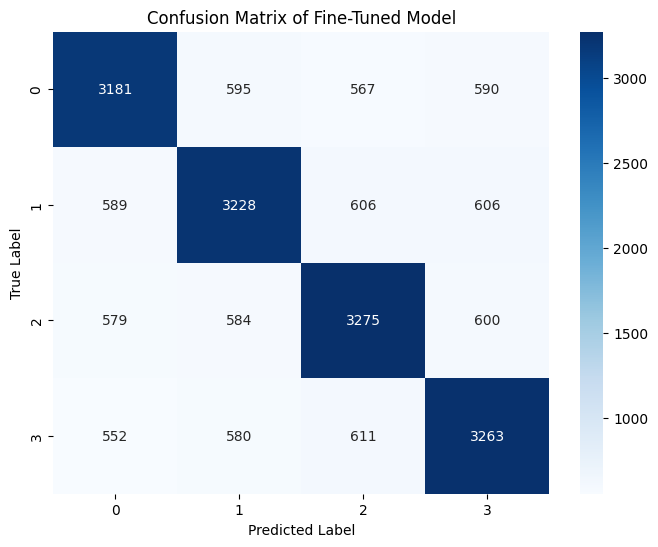

In [34]:
import numpy as np
import torch
from torch.nn import CrossEntropyLoss
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import Trainer, TrainingArguments

# 1. Define simple arguments for the prediction trainer
prediction_args = TrainingArguments(
    output_dir="./swag_lora_finetuned_predict",
    do_train=False,
    do_predict=True,
    per_device_eval_batch_size=8,
    report_to="none",
    fp16=True,
    label_names=["label"],
)

# 2. Create a new, clean Trainer instance for prediction
prediction_trainer = Trainer(
    model=trainer.model,
    args=prediction_args,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

# 3. Generate predictions using the new trainer
print("Generating predictions on the validation set...")
prediction_output = prediction_trainer.predict(test_dataset=validation_dataset)
print("Prediction complete!")

# --- THE FINAL FIX: Extract logits and labels from their correct locations ---

# 1. The actual logits are the SECOND element of the .predictions tuple.
logits_array = prediction_output.predictions[1]

# 2. The label_ids are missing, so we get them directly from the validation_dataset.
true_labels = validation_dataset['label']

true_labels = true_labels[:len(logits_array)]
# --------------------------------------------------------------------------------

# --- Manually Calculate All Metrics ---

# Perplexity
logits_tensor = torch.tensor(logits_array)
labels_tensor = torch.tensor(true_labels).long() # Ensure labels are Long type for loss function
loss_fct = CrossEntropyLoss()
loss = loss_fct(logits_tensor, labels_tensor)
perplexity = torch.exp(loss)
print(f"\nValidation Perplexity: {perplexity:.4f}")

# Accuracy
predicted_labels = np.argmax(logits_array, axis=1)
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Validation Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("\nDisplaying Confusion Matrix:")
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of Fine-Tuned Model")
plt.show()

#### 4. Report Your Results

Validation Accuracy with Fine tune: 0.6472

Validation Accuracy with Instruction Prompting: 0.4746

Validation Accuracy with Few-Shot ICL: 0.4625

Their results are close to each other, for Instruction Prompting and Few-Shot ICL. But Fine tuning has much better performance

### <font color='skyblue'>12. In-Context Learning with the Fine-Tuned Model </font>

In [35]:
import numpy as np
from sklearn.metrics import accuracy_score
from transformers import Trainer, TrainingArguments

# --- 1. Apply the ICL Preprocessing ---
# We reuse the same few-shot function you created earlier.
print("Applying few-shot ICL preprocessing to the validation set...")
tokenized_swag_ft_icl = swag_dataset.map(preprocess_function_few_shot, batched=True)
validation_dataset_icl = tokenized_swag_ft_icl["validation"]


# --- 2. Set up a New, Clean Trainer for Prediction ---
# This uses the fine-tuned model from your previous 'trainer' object.
prediction_args_icl = TrainingArguments(
    output_dir="./swag_lora_finetuned_icl_predict",
    do_train=False,
    do_predict=True,
    per_device_eval_batch_size=8,
    report_to="none",
    fp16=True,
    label_names=["label"],
)

prediction_trainer_icl = Trainer(
    model=trainer.model, # Using the fine-tuned model
    args=prediction_args_icl,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


# --- 3. Generate Predictions ---
print("\nGenerating predictions on the ICL-formatted data...")
prediction_output_icl = prediction_trainer_icl.predict(test_dataset=validation_dataset_icl)
print("Prediction complete!")


# --- 4. Extract Results and Calculate Accuracy ---
# We use the same robust method as before to extract the results.

# The actual logits are the SECOND element of the .predictions tuple.
logits_array_icl = prediction_output_icl.predictions[1]

# Get the true labels directly from the dataset.
true_labels_icl = validation_dataset_icl['label']
true_labels_icl = true_labels_icl[:len(logits_array_icl)] # Ensure length matches

# Calculate final accuracy
predicted_labels_icl = np.argmax(logits_array_icl, axis=1)
accuracy_icl = accuracy_score(true_labels_icl, predicted_labels_icl)

print("\n--- Final Results ---")
print(f"Validation Accuracy with Fine-Tuning + ICL: {accuracy_icl:.4f}")

Applying few-shot ICL preprocessing to the validation set...

Generating predictions on the ICL-formatted data...


/tmp/ipykernel_24562/2155002178.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  prediction_trainer_icl = Trainer(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Prediction complete!

--- Final Results ---
Validation Accuracy with Fine-Tuning + ICL: 0.6106


### <font color='skyblue'>13. Analyse the results  </font>

## Best Performing Method
Fine-tuning was the most effective approach, achieving an accuracy of 64.72%, which is substantially higher than the ~47% accuracy from In-Context Learning (ICL) methods.

This outcome is expected. Fine-tuning is a more powerful process where the model's internal weights are directly updated and optimized for the specific task and data distribution of the SWAG dataset. It allows the model to deeply learn the required reasoning patterns from thousands of examples. In contrast, ICL only guides the model by providing a few examples within the prompt at inference time, without actually changing the model's underlying knowledge. Essentially, fine-tuning creates a 

specialist for the task, while ICL gives temporary instructions to a generalist.

## The Effect of ICL on a Fine-Tuned Model
It is highly unlikely that the fine-tuned model would benefit from ICL; the effect would likely be insignificant or even negative. A model that has been fine-tuned has already learned the patterns of the SWAG task from the entire training set. It no longer needs a few examples in the prompt to understand what to do.

Adding an ICL prompt to a fine-tuned model can introduce noise or distract it. The model was trained to expect inputs in a specific format (context + ending). The ICL prompt changes this format, which could confuse the model and prevent it from applying its specialized knowledge, potentially lowering its accuracy.

## Real-World Scenarios for Combining Fine-Tuning and ICL
Combining fine-tuning and ICL is most powerful when you need a model that is an expert in a broad domain but needs to be flexibly adapted to specific, nuanced tasks in real-time without being retrained.

A great example is a customer support chatbot.

Fine-Tuning: The model would first be fine-tuned on all of the company's internal documentation, product manuals, and past customer support tickets. This makes it a domain expert that understands the company's products and common issues.

In-Context Learning (ICL): A support agent could then use ICL to steer the expert model's behavior for a specific conversation. For instance, if dealing with an angry customer, the agent could prepend the query with a few examples of polite, de-escalating responses. If the goal is to promote a new feature, the prompt could include examples of how to upsell. This allows for real-time control over the model's tone and objective without needing to create a separate fine-tuned model for every possible scenario.

### <font color='skyblue'>Questions </font>

## 1. Fine-tuning a large model like BERT can be powerful but also resource-intensive. In what scenarios might fine-tuning be the best approach? When might you prefer ICL instead? Are there cases where you might combine both?

When to Fine-Tune a Model
Fine-tuning updates a pre-trained model's internal weights by training it further on a specific dataset. Think of it as turning a generalist doctor into a specialist surgeon. This approach is best suited for the following scenarios:

* High Performance is Critical: When we need the highest possible accuracy for a well-defined and stable task, such as classifying customer support tickets or analyzing sentiment for your specific product reviews. Fine-tuning creates an expert model tailored to your data's unique nuances.

* Sufficient Labeled Data: We have a high-quality, labeled dataset, typically consisting of hundreds or thousands of examples. This data is necessary to meaningfully adjust the model's weights without it "forgetting" its original knowledge.

* Domain Adaptation: When our task involves specialized jargon or a style of language not well-represented in general internet text (e.g., legal contracts, scientific papers, medical records). Fine-tuning helps the model learn this new domain-specific language.

* Efficiency at Inference: Once a model is fine-tuned, it doesn't require lengthy instructions or examples in the prompt. This can lead to faster and cheaper predictions, as the prompts are shorter.

When to Prefer In-Context Learning (ICL)
ICL, also known as few-shot prompting, does not update the model's weights. Instead, provide a few examples of the task directly in the prompt to guide the model's response. This is like giving a very smart assistant a few examples of a task before asking them to do it. This method is ideal when:

* Data is Scarce: We have very few labeled examples (e.g., 1 to 10) or none at all (zero-shot). ICL is designed to work with minimal data.

* Rapid Prototyping: We need to quickly test an idea or build a proof-of-concept. It's much faster to write a few examples in a prompt than to prepare a dataset and run a fine-tuning process.

* Tasks are Dynamic or Varied: If we need to perform many different tasks or if the task requirements change often, ICL is more flexible. We can easily change the examples in the prompt without needing to retrain a model.

* Using a Large, Generalist Model: ICL is most effective with powerful, state-of-the-art Large Language Models (LLMs) like GPT-4, which are highly capable of understanding tasks from context alone.

Combining Both Approaches 
The typical scenario is to first fine-tune a model on a broad dataset from your specific domain (e.g., all of your company's internal documentation). This creates a "domain-adapted" model that understands specific terminology, style, and context.

Then, use In-Context Learning with this specialized model to perform various specific, niche tasks.

## 2. In your ICL prompts, you used examples from SWAG. If you had to design a custom ICL prompt for a different task (e.g., predicting medical diagnoses or financial trends), what kinds of examples would you choose? What factors would you consider when selecting them?

When designing a custom In-Context Learning prompt for a new task like predicting medical diagnoses, the key is to choose a small, curated set of examples that teach the model the desired reasoning pattern and output format. I would start with a clear and prototypical example representing the "textbook" version of the task, such as a classic presentation of a common illness, to establish the core logic. To ensure the model generalizes, I'd then introduce diversity with examples that cover different scenarios or require differentiation, like distinguishing between a viral and bacterial infection. It's also crucial to include a nuanced example to show the model how to handle ambiguity, such as a case with confounding factors. Throughout this selection, I would enforce strict structural consistency, ensuring every example follows the exact same format (e.g., Evidence -> Reasoning -> Conclusion) to teach the model not just the correct answer, but the precise structure of the desired output.